# 🌐 Deep Spherical 360° Stitching Pipeline
### SIFT Features · CLAHE Lighting Normalisation · Bundle Adjustment · OpenCV Stitcher

---

## 📋 Overview
This notebook implements a **production-grade spherical panorama stitcher** designed
specifically for **classroom / indoor 360° photography** with 30 images.  
It solves three real-world problems that basic stitchers fail at:

| Problem | Solution |
|---------|----------|
| 🌑 Uneven lighting across 30 shots | **CLAHE** brightness equalisation in LAB colour space |
| 📐 Planar warping distortion | **Spherical Warping** via `cv2.Stitcher_PANORAMA` mode |
| 🔍 Weak feature matching (ORB/AKAZE) | **SIFT** — highest accuracy for complex indoor scenes |

---

## 🏗️ Full Pipeline
```
📁 data2/  (30 images)
      │
      ▼
┌──────────────────────────┐
│   _prepare_data()        │
│  • Sort filenames        │
│  • Resize to width=600px │
│  • BGR → LAB             │
│  • CLAHE on L-channel    │
│  • LAB → BGR             │
└────────────┬─────────────┘
             │
             ▼
┌──────────────────────────┐
│   run_proper_stitch()    │
│  • Stitcher_PANORAMA     │
│  • SIFT feature detect   │
│  • Feature matching      │
│  • Bundle Adjustment     │
│  • Spherical Warping     │
│  • Multi-band Blending   │
└────────────┬─────────────┘
             │
             ▼
┌──────────────────────────┐
│   auto_crop()            │
│  • Grayscale threshold   │
│  • External contours     │
│  • Bounding rect crop    │
└────────────┬─────────────┘
             │
             ▼
  proper_360_stitch.jpg  ✅
```

---

## 🔬 Class: `DeepSphericalStitcher`
```python
DeepSphericalStitcher(folder_path, resize_width=600)
```

### Methods

| Method | Parameters | Description |
|--------|-----------|-------------|
| `__init__` | `folder_path`, `resize_width=600` | Initialises pipeline, calls `_prepare_data()`, creates SIFT detector |
| `_prepare_data` | — | Loads → resizes → CLAHE normalises all images |
| `run_proper_stitch` | — | Runs full OpenCV stitcher with bundle adjustment + spherical warp |
| `auto_crop` | `img` | Removes black border artifacts via contour bounding rect |
| `_explain_error` | `status` | Prints human-readable error for failed stitch status codes |

---

## ⚙️ Configuration

| Parameter | Default | Effect |
|-----------|---------|--------|
| `folder_path` | `'data2'` | Folder containing your 30 input images |
| `resize_width` | `600` | Target width in pixels — height scales proportionally |
| `clipLimit` (CLAHE) | `2.0` | Higher = more aggressive contrast boost |
| `tileGridSize` (CLAHE) | `(8, 8)` | Tile size for local histogram equalisation |

> 💡 **Tip:** Increase `resize_width` to `800`–`1000` for a higher-resolution final panorama,
> but expect longer processing time and higher memory usage.

---

## 🔆 CLAHE Lighting Normalisation

Fixes the most common indoor 360° problem — **mixed exposure** (bright windows + dark corners).
```
Original Image (BGR)
      │
      ▼
  BGR → LAB colour space
      │
      ├── L channel  (Lightness)  ← CLAHE applied here only
      ├── A channel  (Green–Red)  ← unchanged
      └── B channel  (Blue–Yellow)← unchanged
            │
            ▼
      Merge (L_enhanced, A, B)
            │
            ▼
  LAB → BGR colour space  ✅ Balanced brightness
```

> ⚠️ CLAHE is applied **only to the L (lightness) channel** to avoid colour distortion.

---

## 🔑 Why SIFT over ORB / AKAZE?

| Feature | ORB | AKAZE | SIFT |
|---------|-----|-------|------|
| Scale invariance | ✅ | ✅ | ✅ |
| Rotation invariance | ✅ | ✅ | ✅ |
| Indoor scene accuracy | ⚠️ Low | ⚠️ Moderate | ✅ High |
| Handles low contrast | ❌ | ⚠️ | ✅ |
| Speed | ⚡ Fastest | 🔶 Medium | 🐢 Slowest |
| Patent status | Free | Free | Free (since 2020) |

> SIFT is the best choice for a **classroom with mixed lighting, screens, and people**.

---

## 🗺️ Stitching Mode: PANORAMA vs SCANS

| Mode | Warping | Best For |
|------|---------|----------|
| `cv2.Stitcher_PANORAMA` | **Spherical** | 360° sweeps, wide FOV, handheld rotation |
| `cv2.Stitcher_SCANS` | **Planar** | Flat surfaces — documents, whiteboards, maps |

> This pipeline uses **PANORAMA mode** which automatically applies:
> **Bundle Adjustment** → optimises all 30 camera poses simultaneously  
> **Spherical Warping** → maps images onto a sphere to avoid edge distortion

---

## 📊 Status Codes & Fixes

| Code | Constant | Meaning | Fix |
|------|----------|---------|-----|
| `0` | `Stitcher_OK` | ✅ Success | — |
| `1` | `ERR_NEED_MORE_IMGS` | Not enough overlap | Reshoot with 30–40% overlap per frame |
| `2` | `ERR_HOMOGRAPHY_EST_FAIL` | No matching features found | Check for blurry/dark images; CLAHE helps |
| `3` | `ERR_CAMERA_PARAMS_ADJUST_FAIL` | Camera geometry mismatch | Keep consistent zoom and orientation |

---

## 📁 Expected Folder Structure
```
data2/
    ├── 20260306_114220.jpg
    ├── 20260306_114220(0).jpg
    ├── 20260306_114220(1).jpg
    ├── 20260306_114221.jpg
    └── ...  (30 images total)
```

> 💡 Images are loaded with `sorted()` alphabetically.
> For bracket-style filenames like `114220(0)`, ensure naming is consistent
> so sort order matches your physical capture sequence.

---

## 📦 Dependencies
```python
opencv-contrib-python    # SIFT requires contrib build
numpy
google-colab             # cv2_imshow
```
```bash
# Install in Colab
!pip install opencv-contrib-python
```

---

## 🚀 Quick Start
```python
# Point to your image folder and run
pipeline = DeepSphericalStitcher('data2')
pipeline.run_proper_stitch()
# Output saved as: proper_360_stitch.jpg
```

---

## 🐛 Troubleshooting

| Issue | Cause | Fix |
|-------|-------|-----|
| `Status Code: 1` | Too few matching features | Ensure 30–40% overlap between consecutive shots |
| `Status Code: 2` | Blurry or too-dark images | CLAHE is already applied; check source image quality |
| Out of memory crash | `resize_width` too high | Lower to `400` or `300` |
| Blurry panorama output | `resize_width` too low | Increase to `800` for final export |
| Black borders in output | Normal spherical warp artifact | Already handled by `auto_crop()` |
| Wrong stitch order | Alphabetical sort mismatch | Rename files with zero-padded sequential numbers |

✅ Pre-processed 30 images for Spherical Stitching.
🚀 Starting Global Bundle Adjustment for 30 images...
✨ Stitching Successful!


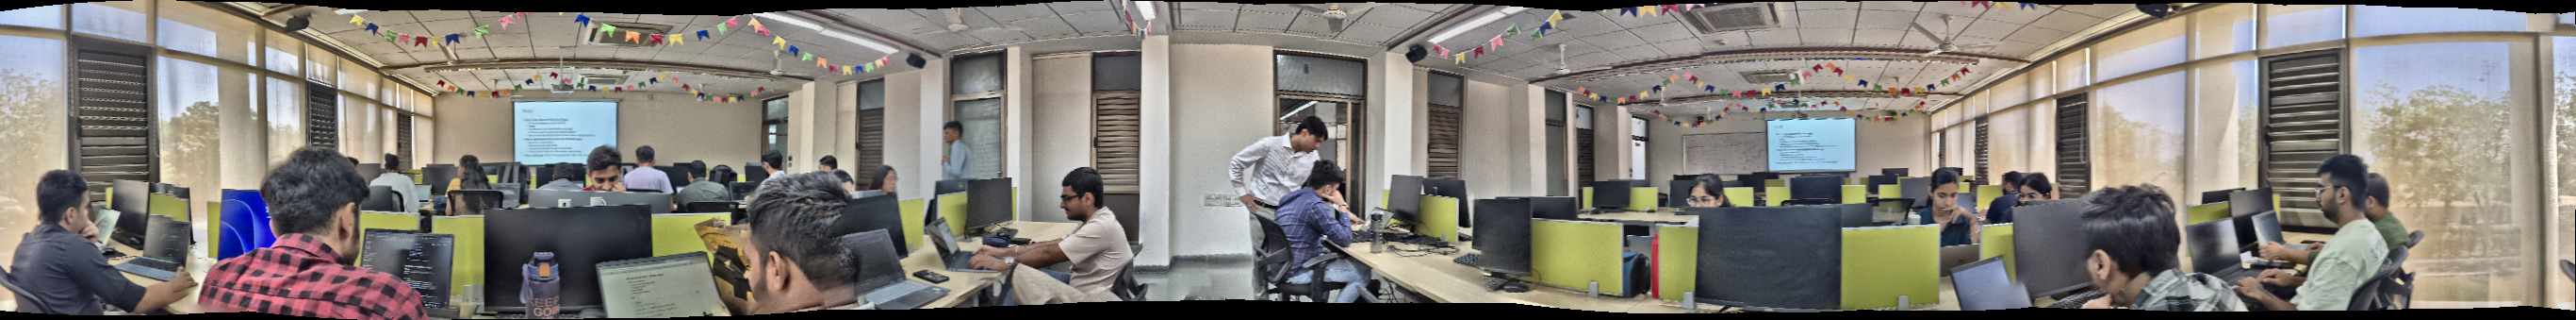

In [1]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

class DeepSphericalStitcher:
    def __init__(self, folder_path, resize_width=600):
        self.folder_path = folder_path
        self.resize_width = resize_width
        self.images = self._prepare_data()
        # Using SIFT for high-accuracy feature matching in a classroom environment
        self.finder = cv2.SIFT_create()

    def _prepare_data(self):
        """Loads images and normalizes lighting to fix dark areas."""
        files = sorted([f for f in os.listdir(self.folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        processed = []
        for f in files:
            img = cv2.imread(os.path.join(self.folder_path, f))
            if img is not None:
                h, w = img.shape[:2]
                img = cv2.resize(img, (self.resize_width, int(h * (self.resize_width/w))))

                # Apply CLAHE to equalize brightness across the 30 images
                lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                l = clahe.apply(l)
                img = cv2.merge((l, a, b))
                processed.append(cv2.cvtColor(img, cv2.COLOR_LAB2BGR))
        print(f"✅ Pre-processed {len(processed)} images for Spherical Stitching.")
        return processed

    def run_proper_stitch(self):
        """
        Uses the OpenCV Stitcher class configured for high-depth 360 panoramas.
        This handles Bundle Adjustment and Spherical Warping automatically.
        """
        # Create a Stitcher object specifically for PANORAMA mode
        # This mode uses Spherical Warping instead of Planar Warping
        stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

        print("🚀 Starting Global Bundle Adjustment for 30 images...")
        # This is the 'Proper' way: it optimizes all 30 images simultaneously
        status, panorama = stitcher.stitch(self.images)

        if status == cv2.Stitcher_OK:
            # Post-process: Crop the wavy black edges
            final_result = self.auto_crop(panorama)
            print("✨ Stitching Successful!")
            cv2_imshow(final_result)
            cv2.imwrite('proper_360_stitch.jpg', final_result)
        else:
            print(f"❌ Stitching failed with Status Code: {status}")
            self._explain_error(status)

    def auto_crop(self, img):
        """Removes the irregular black borders created by spherical projection."""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)[1]
        cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            return img[y:y+h, x:x+w]
        return img

    def _explain_error(self, status):
        errors = {
            1: "ERR_NEED_MORE_IMGS: Not enough overlap between your 30 images.",
            2: "ERR_HOMOGRAPHY_EST_FAIL: Could not find matching points (too dark or blurry).",
            3: "ERR_CAMERA_PARAMS_ADJUST_FAIL: Camera geometry mismatch."
        }
        print(errors.get(status, "Unknown error."))

# --- MAIN EXECUTION ---
# Ensure your 30 images are in the 'data2' folder
pipeline = DeepSphericalStitcher('/content/data')
pipeline.run_proper_stitch()